In [1]:
import joblib
import sys
import glob
import numpy as np
import pandas as pd
import scipy.stats as ss
import scipy.spatial.distance as dst
import itertools

import os
os.environ['MPLCONFIGDIR'] = os.getcwd() + "/configs/"
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

sys.path.append('../scripts')
import core
from analyse import aname, bname

In [2]:
colors = {
    'C': 'navy',
    'G': 'seagreen',
    'N': 'orangered',
    'GB':'crimson',
    'CB':'darkorchid',
    'GM':'mediumturquoise',
    'CM':'darkcyan',
}
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.bottom'] = True
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 2

def generate_colormap(color, linspace=16):
    rgb_vals = mpl.colors.to_rgb(color)
    x = np.array([np.linspace(i,0.92,16) for i in rgb_vals])
    cm = LinearSegmentedColormap.from_list(
        'listname', x.T, N=16
    )
    return cm, np.append(x, np.repeat(1, 16)[:, None].T, axis=0)

In [3]:
dataset = 'naive'
method = 'pls'
win = 100
nbasis = 15
training_conditions = ['C', 'G', 'N', 'CM']
ncomps = np.arange(50, 0, -1)

In [5]:
win=100
nbasis=15
exp = 'nat8b'
dataset = 'cohort'

stim_info = pd.read_csv(f"../inputs/stimuli/{exp}-info.csv")
spectrograms = pd.read_csv(f"../build/{exp}/spectrograms.csv", index_col=[0,1])
motifs = stim_info.motif.unique()
gaps = stim_info[stim_info.type=='G'].groupby(['motif','gap']).first()[['gap_start', 'gap_stop']]
gaplocs = gaps.index.levels[1].to_numpy().astype(int)
dsetdata = []
for h5file in glob.glob(f"../build/{exp}/**_delemb_win{win}_basis{nbasis}.h5"):
    dsetdata.append(pd.read_hdf(h5file, key='Induction'))
responses = pd.concat(dsetdata, axis=1)
models = joblib.load(f"../output/{exp}/{dataset}_PLS_models.pkl")
model = models['all']

projections = []
for m in motifs:
    cstim = spectrograms.loc[bname(m, 'C', None)]
    for g in gaplocs:
        ga, gb = gaps.loc[m].loc[g].astype(int)
        for c in ['C','G','CB', 'GB', 'N', 'GM', 'CM']:
            stim = bname(m, c, g)
            X = model.transform(
                X = responses.loc[stim].loc[ga:gb]
            )
            projections.append({
                'motif': m,
                'gap': g,
                'condition': c,
                'projections': X
            })
result = pd.DataFrame(projections).set_index(['motif', 'gap', 'condition'])

distmap = []
for i, (m, g) in enumerate(itertools.product(motifs, gaplocs)):
    CI_proj = result.loc[m, g, 'C'].projections[:,:3]
    CI_dist = [dst.euclidean(x, [1,-1,-2]) for x in CI_proj]
    distmap.append({
        'motif':m,
        'gap':g,
        'avg': np.mean(CI_dist)
    })
distmap = pd.DataFrame(distmap).sort_values('avg')
distmap['distrank'] = np.arange(16)
distmap['viridiscolor'] = [mpl.colormaps['viridis'](x) for x in np.linspace(0,1,16)]
distmap.set_index(['motif','gap'], inplace=True)
distmap.head()

avg  distrank                         viridiscolor
motif   gap                                                         
nat8mk2 2    2.001998         0  (0.267004, 0.004874, 0.329415, 1.0)
nat8mk3 1    2.033600         1   (0.282656, 0.100196, 0.42216, 1.0)
nat8mk4 1    2.077981         2  (0.277134, 0.185228, 0.489898, 1.0)
nat8mk5 1    2.168951         3  (0.253935, 0.265254, 0.529983, 1.0)
        2    2.173140         4  (0.221989, 0.339161, 0.548752, 1.0)

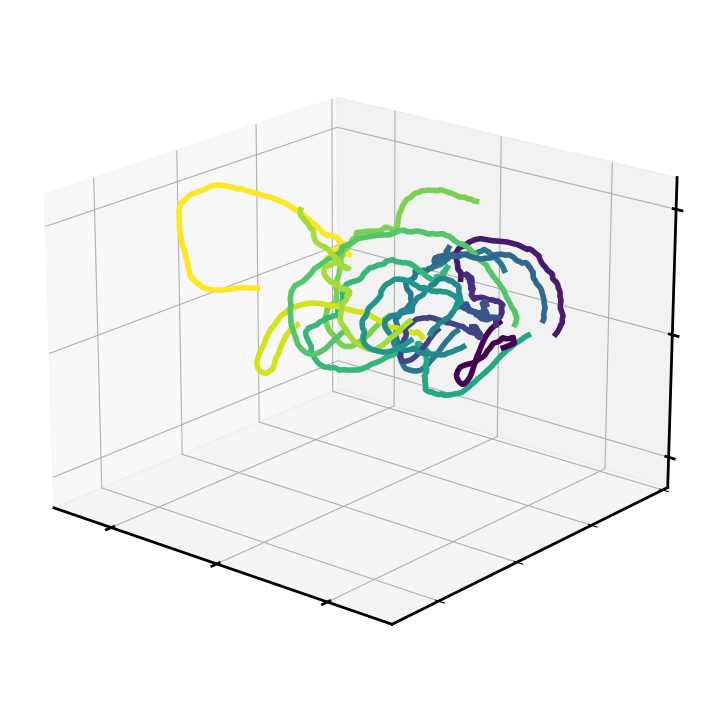

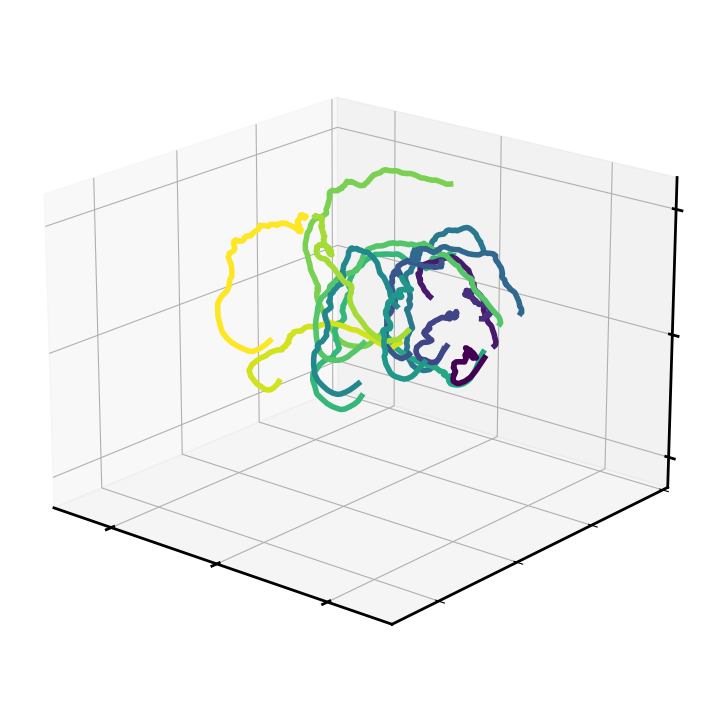

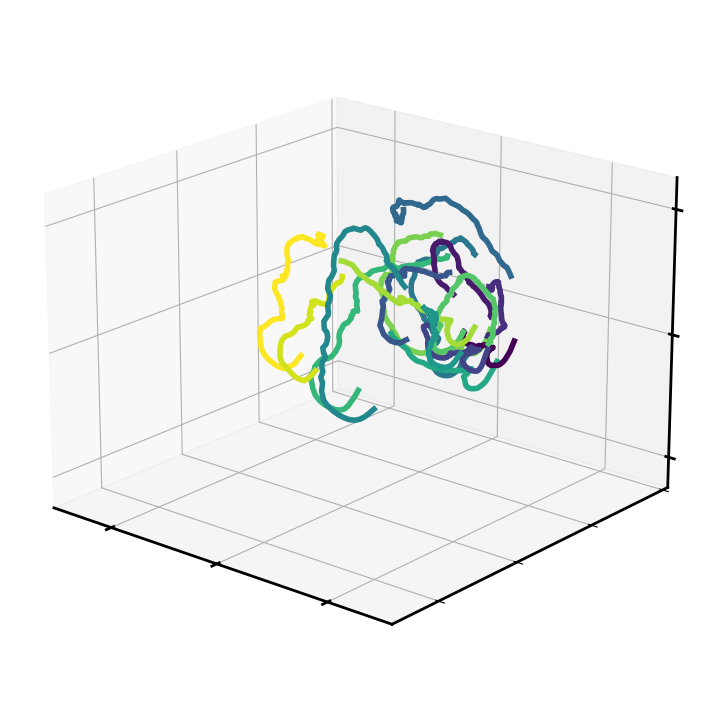

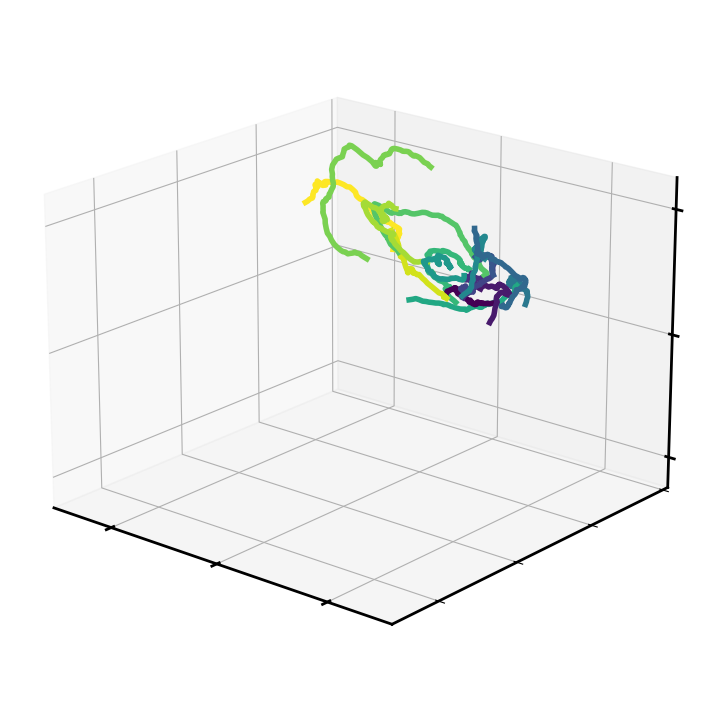

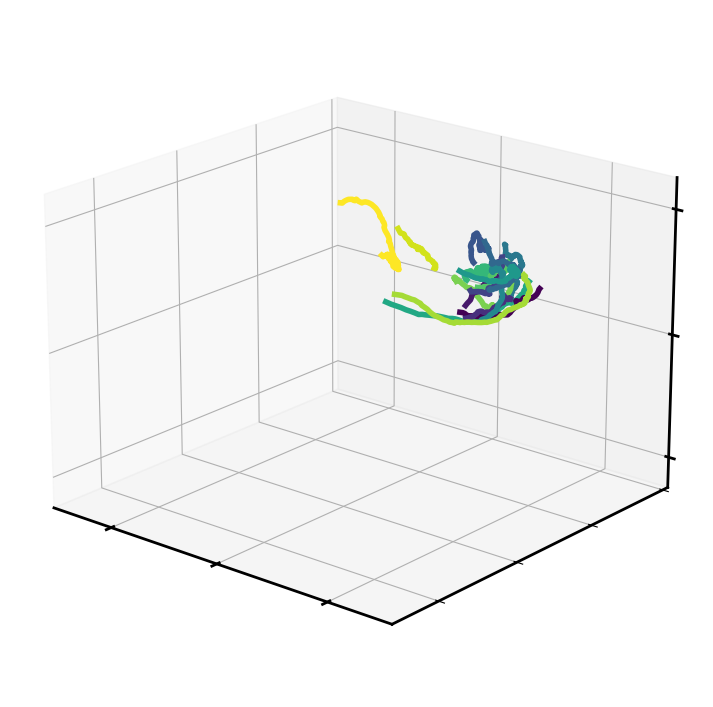

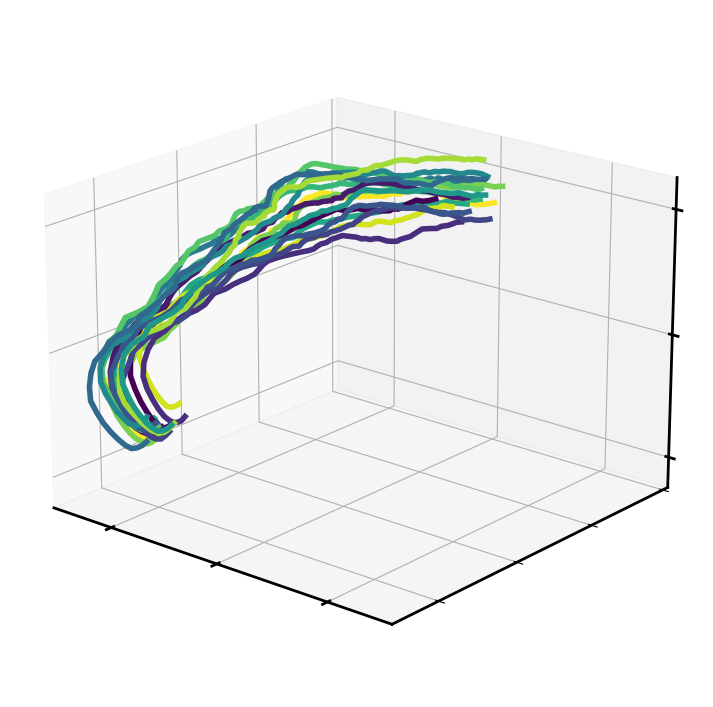

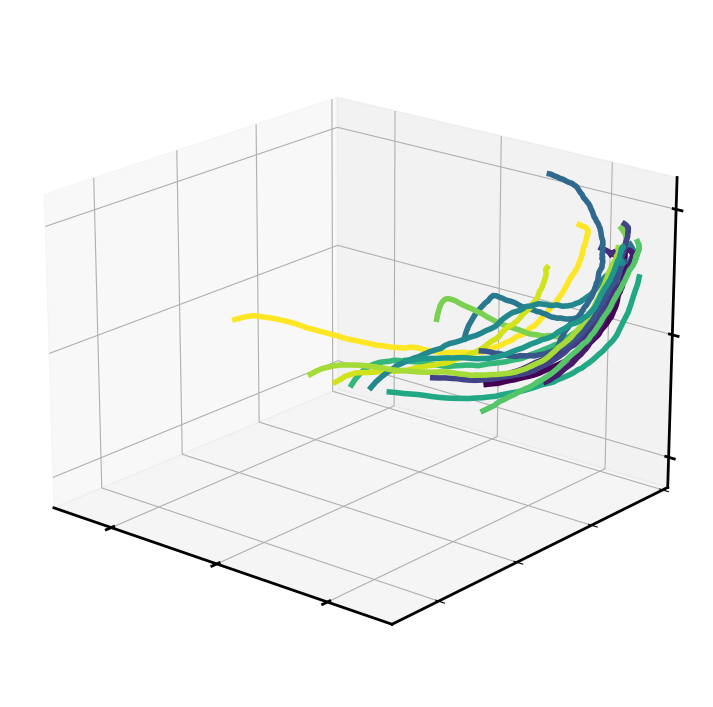

In [11]:
colbar=False
for c in ['C','CB','GB','CM','GM','N','G']:
    fig = plt.figure(figsize=(10,9))
    ax = fig.add_subplot(1,9,(2,9),projection='3d')
    plt.setp(ax.spines.values(), lw=3, color='black')
    cm, colormap = generate_colormap(colors[c])
    for i, (m, g) in enumerate(itertools.product(motifs, gaplocs)):
        projs = result.loc[m, g, c].projections
        img = ax.plot(
            projs[:, 0],
            projs[:, 1],
            projs[:, 2],
            alpha=1,
            color= distmap.loc[m,g].viridiscolor,
            lw=4
        )
    ax.view_init(elev=20, azim=130, roll=0)
    ax.set_xlim(0.5,3.5)
    ax.set_xticks([1,2,3], [])
    ax.set_ylim(-0.5,2.5)
    ax.set_yticks([-1,0,1,2], [])
    ax.set_zlim(-2.2,0.2)
    ax.set_zticks([-2,-1,0], [])

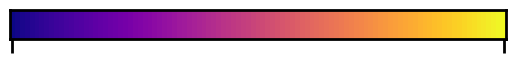

In [12]:
max_proj = result.apply(lambda row: row.projections.shape[0], axis=1).max()
cmap_vals = np.linspace(0,1,max_proj)
plt.rcParams['axes.linewidth'] = 2

plt.rcParams['xtick.bottom'] = True
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 2

clbax = plt.figure().add_subplot()
gradient = np.vstack((cmap_vals, cmap_vals, cmap_vals))
clbax.imshow(gradient, cmap='plasma', aspect=2)
clbax.set_xticks([0,max_proj-1],[])
clbax.set_yticks([]);

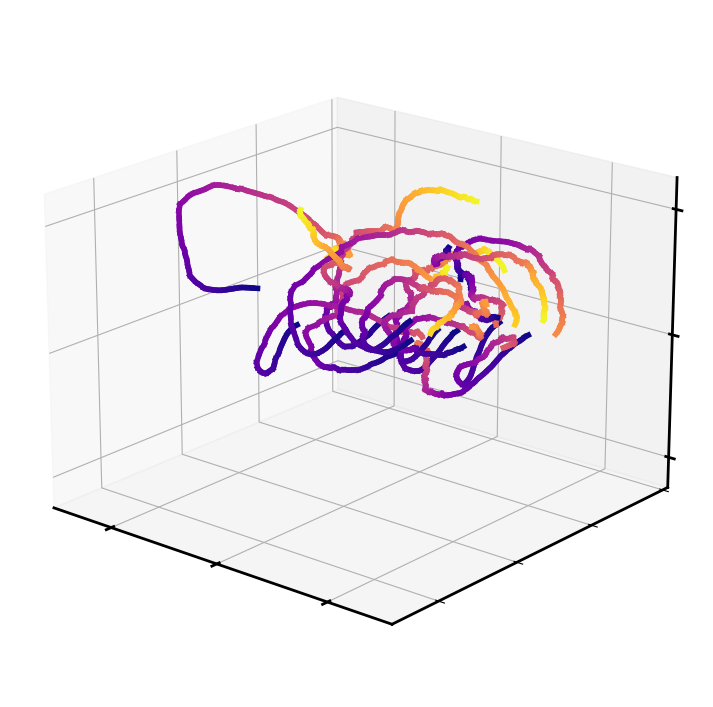

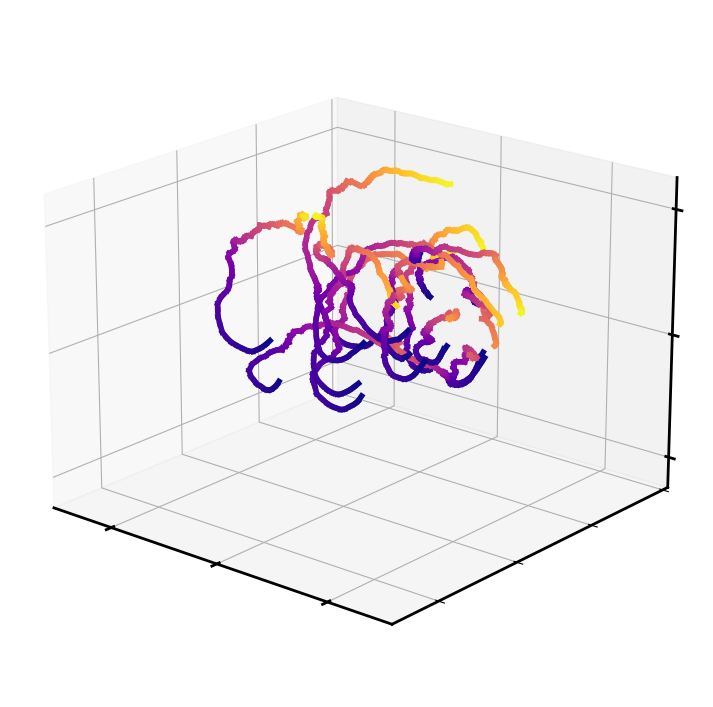

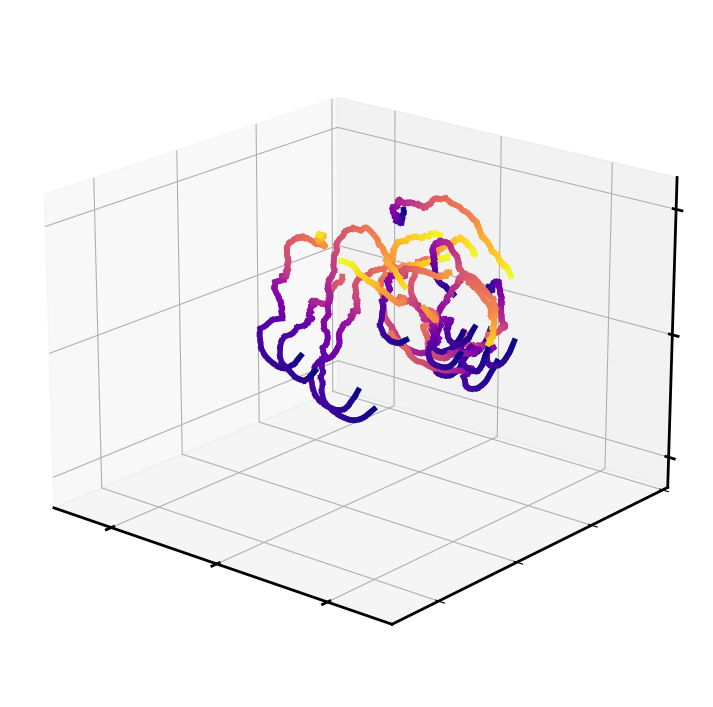

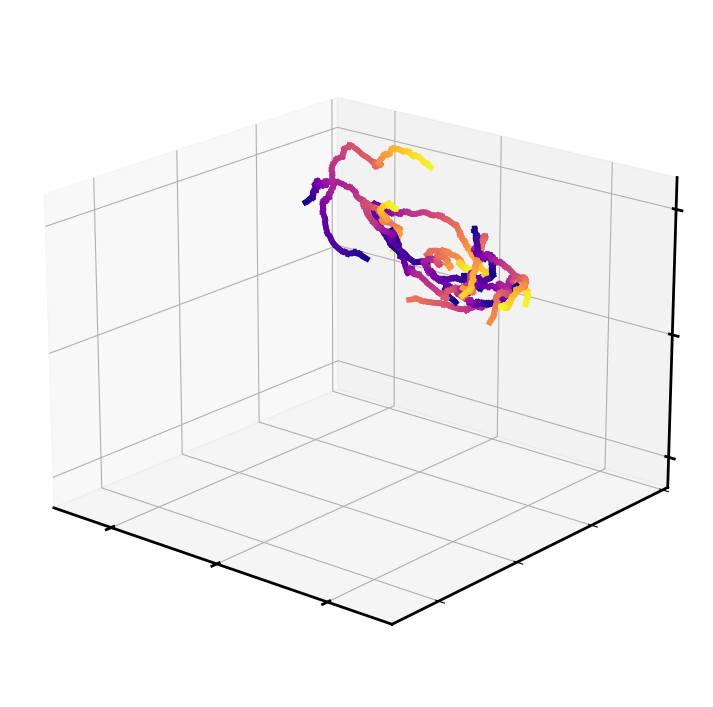

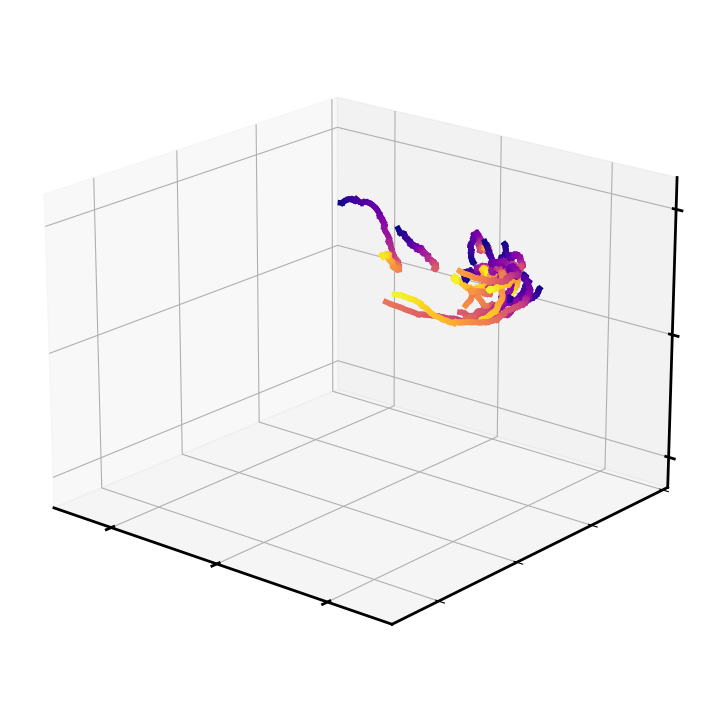

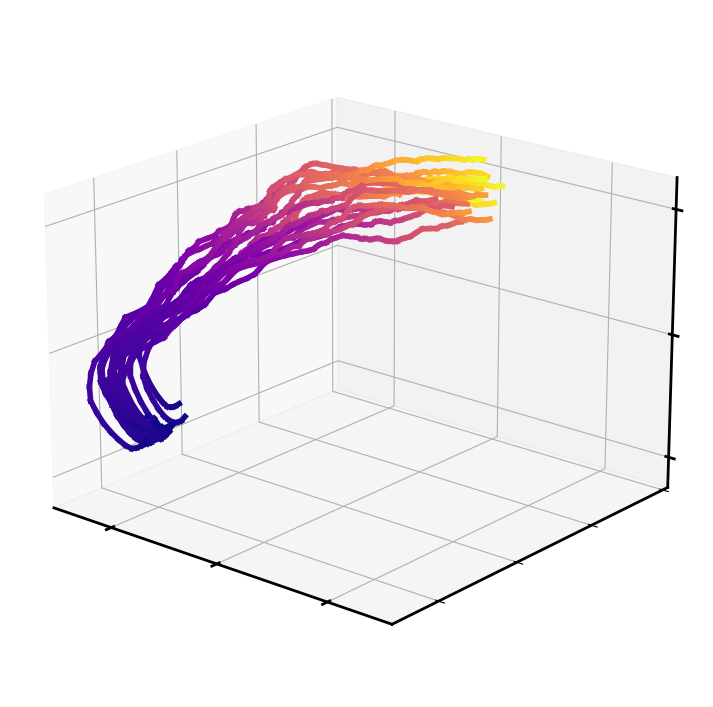

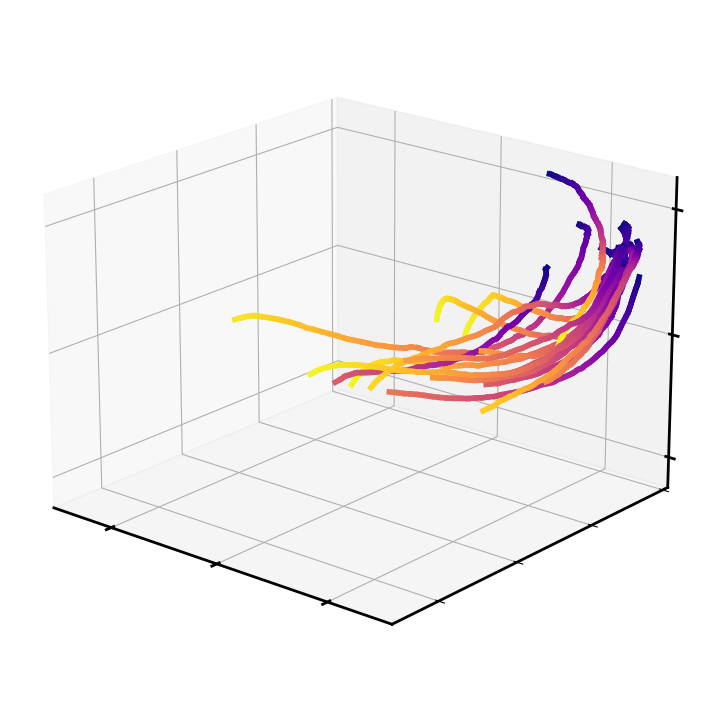

In [10]:
for c in ['C','CB','GB','CM','GM','N','G']:
    fig = plt.figure(figsize=(10,9))
    ax = fig.add_subplot(1,9,(2,9),projection='3d')
    plt.setp(ax.spines.values(), lw=3, color='black')
    for i, (m, g) in enumerate(itertools.product(motifs, gaplocs)):
        projs = result.loc[m, g, c].projections
        for idx in range(projs.shape[0]-1):
            ax.plot(
                projs[idx:idx+2, 0],
                projs[idx:idx+2, 1],
                projs[idx:idx+2, 2],
                alpha=1,
                color=mpl.colormaps['plasma'](cmap_vals[idx]),
                #cmap='plasma',#colormap[:,int(distmap.loc[m,g].distrank)],
                lw=4
            )
    ax.view_init(elev=20, azim=130, roll=0)
    ax.set_xlim(0.5,3.5)
    ax.set_xticks([1,2,3], [])
    ax.set_ylim(-0.5,2.5)
    ax.set_yticks([-1,0,1,2], [])
    ax.set_zlim(-2.2,0.2)
    ax.set_zticks([-2,-1,0], [])